
MODULE 1 : CLASS DEFINITION

LABELED DATA CREATED

CLASS DISTRIBUTION
Class_Label
0    788
1    413
2     25
Name: count, dtype: int64

MODULE 2 : FEATURE ENGINEERING

FEATURE MATRIX
                           reading  humidity  Delta  Rolling_Var
time                                                            
2023-01-06 19:00:00-03:00     27.2      82.6    0.0          0.0
2023-01-06 20:00:00-03:00     27.0      83.0   -0.2          0.0
2023-01-06 21:00:00-03:00     27.0      83.0    0.0          0.0
2023-01-06 22:00:00-03:00     26.7      83.9   -0.3          0.0
2023-01-06 23:00:00-03:00     26.5      85.4   -0.2          0.0

MODULE 3 : MODEL EXECUTION

MODEL TRAINING COMPLETED

MODULE 4 : PERFORMANCE EXPLORATION

--- INDUSTRIAL CLASSIFICATION REPORT ---

Overall Accuracy : 100.0 %

CONFUSION MATRIX
[[158   0   0]
 [  0  83   0]
 [  0   0   5]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Optimal       1.00      1.00      1.00       158
     

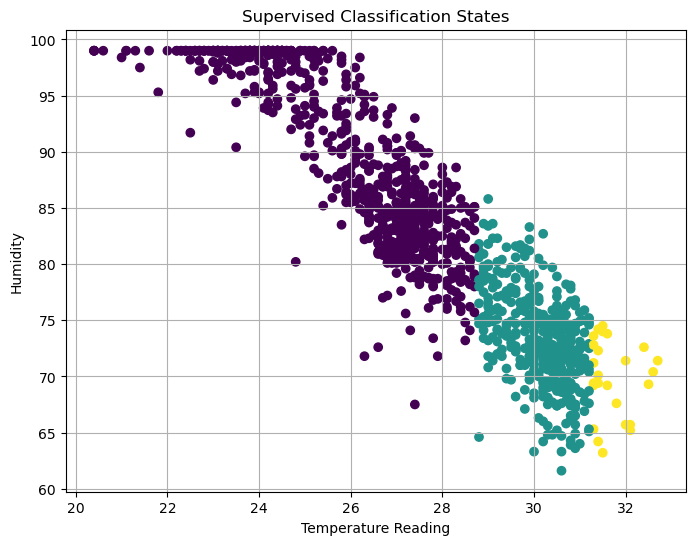


PR_26 PRACTICAL COMPLETED


In [2]:
# ==========================================
# PR_26
# Analytical Models That Assign Datasets
# Into Predefined Classes Based on Patterns
# ==========================================

# ---------- IMPORT LIBRARIES ----------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)


# ==========================================
# MODULE 1 : CLASS DEFINITION AND LABELING
# ==========================================

"""
DEFINITION:
Classification requires predefined
ground-truth labels for supervised learning.
"""

print("\n===================================")
print("MODULE 1 : CLASS DEFINITION")
print("===================================")

# Load dataset
df = pd.read_csv("B2K weather station.csv")

# Rename columns
df.rename(columns={
    'Data': 'time',
    'Temperatura': 'reading',
    'Humidade': 'humidity'
}, inplace=True)

# Convert datetime column
df['time'] = pd.to_datetime(
    df['time'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

# Remove invalid datetime rows
df = df.dropna(subset=['time'])

# Set datetime index
df = df.set_index('time')

# Sort sequentially
df = df.sort_index()

# Convert numerical columns
df['reading'] = pd.to_numeric(
    df['reading'],
    errors='coerce'
)

df['humidity'] = pd.to_numeric(
    df['humidity'],
    errors='coerce'
)

# Remove invalid rows
df = df.dropna()

# ---------- CLASS LABEL CREATION ----------

# Mean and standard deviation
mean = df['reading'].mean()

std = df['reading'].std()

# Threshold-based classification
conditions = [

    (df['reading'] <= mean + 0.5 * std),

    (
        (df['reading'] > mean + 0.5 * std)
        &
        (df['reading'] <= mean + 1.5 * std)
    ),

    (df['reading'] > mean + 1.5 * std)

]

# Assign labels
df['Class_Label'] = np.select(
    conditions,
    [0, 1, 2],
    default=0
)

# Save labeled dataset
df.to_parquet(
    "labeled_training_data.parquet",
    compression='snappy'
)

print("\nLABELED DATA CREATED")

# Display class counts
print("\nCLASS DISTRIBUTION")
print(
    df['Class_Label']
    .value_counts()
)


# ==========================================
# MODULE 2 : FEATURE ENGINEERING
# ==========================================

"""
DEFINITION:
Feature engineering creates derived
patterns for supervised learning.
"""

print("\n===================================")
print("MODULE 2 : FEATURE ENGINEERING")
print("===================================")

# Delta feature
df['Delta'] = (
    df['reading']
    .diff()
    .fillna(0)
)

# Rolling variance feature
df['Rolling_Var'] = (

    df['reading']

    .rolling(window=10)

    .var()

    .fillna(0)
)

# Feature matrix
X = df[
    [
        'reading',
        'humidity',
        'Delta',
        'Rolling_Var'
    ]
]

# Target labels
y = df['Class_Label']

print("\nFEATURE MATRIX")
print(X.head())


# ==========================================
# MODULE 3 : MODEL EXECUTION
# ==========================================

"""
DEFINITION:
Random Forest creates multiple
decision trees for classification.
"""

print("\n===================================")
print("MODULE 3 : MODEL EXECUTION")
print("===================================")

# Partition dataset
X_train, X_test, y_train, y_test = (

    train_test_split(

        X,
        y,

        test_size=0.2,

        random_state=42,

        stratify=y
    )
)

# Random Forest model
clf = RandomForestClassifier(

    n_estimators=150,

    max_depth=10,

    random_state=42
)

# Train model
clf.fit(
    X_train,
    y_train
)

# Predict classes
y_pred = clf.predict(
    X_test
)

print("\nMODEL TRAINING COMPLETED")


# ==========================================
# MODULE 4 : PERFORMANCE EXPLORATION
# ==========================================

"""
DEFINITION:
Evaluation metrics validate
classification reliability.
"""

print("\n===================================")
print("MODULE 4 : PERFORMANCE EXPLORATION")
print("===================================")

# Accuracy
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n--- INDUSTRIAL CLASSIFICATION REPORT ---")

print(
    "\nOverall Accuracy :",
    round(accuracy * 100, 2),
    "%"
)

# Confusion matrix
print("\nCONFUSION MATRIX")

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[0,1,2]
)

print(cm)

# Classification report
print("\nCLASSIFICATION REPORT")

report = classification_report(

    y_test,

    y_pred,

    labels=[0,1,2],

    target_names=[
        'Optimal',
        'Warning',
        'Critical'
    ],

    zero_division=0
)

print(report)


# ==========================================
# MODULE 5 : VISUALIZATION
# ==========================================

"""
DEFINITION:
Visualization explores
predicted operational states.
"""

print("\n===================================")
print("MODULE 5 : VISUALIZATION")
print("===================================")

# Scatter visualization
plt.figure(figsize=(8,6))

plt.scatter(

    df['reading'],

    df['humidity'],

    c=df['Class_Label']

)

plt.xlabel("Temperature Reading")

plt.ylabel("Humidity")

plt.title(
    "Supervised Classification States"
)

plt.grid(True)

plt.show()


# ==========================================
# FINAL OUTPUT
# ==========================================

print("\n===================================")
print("PR_26 PRACTICAL COMPLETED")
print("===================================")


MODULE 1 : CLASS DEFINITION

LABELED DATA CREATED

CLASS DISTRIBUTION
Class_Label
Optimal     788
Warning     413
Critical     25
Name: count, dtype: int64

MODULE 2 : FEATURE ENGINEERING

FEATURE MATRIX
                           reading  humidity  Delta  Rolling_Var
time                                                            
2023-01-06 19:00:00-03:00     27.2      82.6    0.0          0.0
2023-01-06 20:00:00-03:00     27.0      83.0   -0.2          0.0
2023-01-06 21:00:00-03:00     27.0      83.0    0.0          0.0
2023-01-06 22:00:00-03:00     26.7      83.9   -0.3          0.0
2023-01-06 23:00:00-03:00     26.5      85.4   -0.2          0.0

MODULE 3 : MODEL EXECUTION

MODEL TRAINING COMPLETED

MODULE 4 : PERFORMANCE EXPLORATION

--- INDUSTRIAL CLASSIFICATION REPORT ---

Overall Accuracy : 100.0 %

CONFUSION MATRIX
[[158   0   0]
 [  0  83   0]
 [  0   0   5]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Optimal       1.00      1.00     

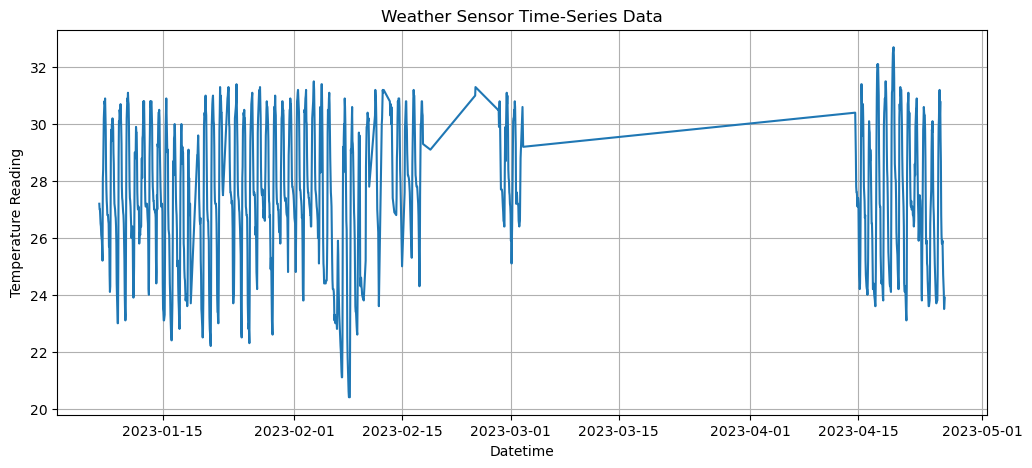

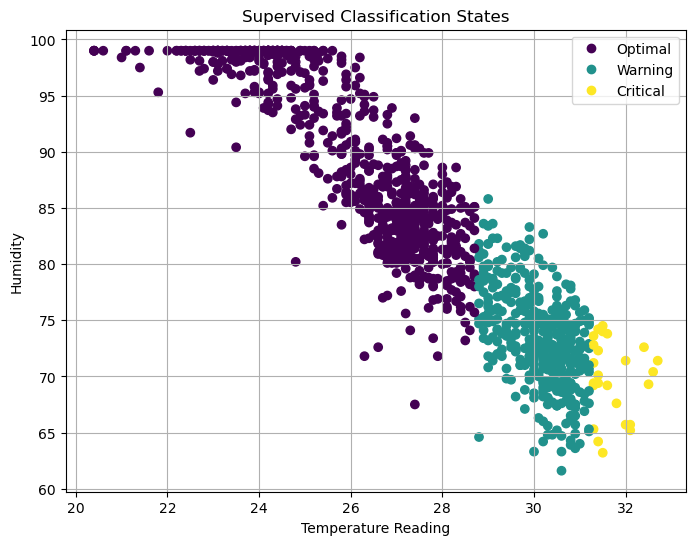

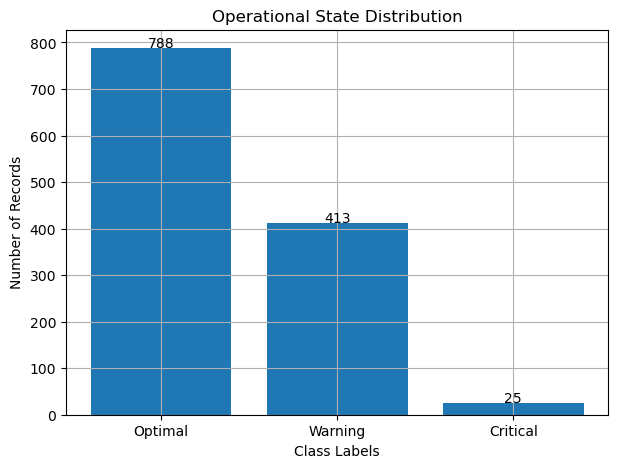


PR_26 PRACTICAL COMPLETED


In [6]:
# ==========================================
# PR_26
# Analytical Models That Assign Datasets
# Into Predefined Classes Based on Patterns
# ==========================================

# ---------- IMPORT LIBRARIES ----------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)


# ==========================================
# MODULE 1 : CLASS DEFINITION AND LABELING
# ==========================================

"""
DEFINITION:
Classification requires predefined
ground-truth labels for supervised learning.
"""

print("\n===================================")
print("MODULE 1 : CLASS DEFINITION")
print("===================================")

# Load dataset
df = pd.read_csv("B2K weather station.csv")

# Rename columns
df.rename(columns={
    'Data': 'time',
    'Temperatura': 'reading',
    'Humidade': 'humidity'
}, inplace=True)

# Convert datetime column
df['time'] = pd.to_datetime(
    df['time'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

# Remove invalid datetime rows
df = df.dropna(subset=['time'])

# Set datetime index
df = df.set_index('time')

# Sort sequentially
df = df.sort_index()

# Convert numerical columns
df['reading'] = pd.to_numeric(
    df['reading'],
    errors='coerce'
)

df['humidity'] = pd.to_numeric(
    df['humidity'],
    errors='coerce'
)

# Remove invalid rows
df = df.dropna()

# ---------- CLASS LABEL CREATION ----------

# Mean and standard deviation
mean = df['reading'].mean()

std = df['reading'].std()

# Threshold conditions
conditions = [

    (df['reading'] <= mean + 0.5 * std),

    (
        (df['reading'] > mean + 0.5 * std)
        &
        (df['reading'] <= mean + 1.5 * std)
    ),

    (df['reading'] > mean + 1.5 * std)

]

# Assign class labels
df['Class_Label'] = np.select(

    conditions,

    [
        'Optimal',
        'Warning',
        'Critical'
    ],

    default='Optimal'
)

# Save labeled dataset
df.to_parquet(
    "labeled_training_data.parquet",
    compression='snappy'
)

print("\nLABELED DATA CREATED")

# Display class counts
print("\nCLASS DISTRIBUTION")

print(
    df['Class_Label']
    .value_counts()
)


# ==========================================
# MODULE 2 : FEATURE ENGINEERING
# ==========================================

"""
DEFINITION:
Feature engineering creates derived
patterns for supervised learning.
"""

print("\n===================================")
print("MODULE 2 : FEATURE ENGINEERING")
print("===================================")

# Delta feature
df['Delta'] = (

    df['reading']

    .diff()

    .fillna(0)
)

# Rolling variance feature
df['Rolling_Var'] = (

    df['reading']

    .rolling(window=10)

    .var()

    .fillna(0)
)

# Feature matrix
X = df[
    [
        'reading',
        'humidity',
        'Delta',
        'Rolling_Var'
    ]
]

# Target labels
y = df['Class_Label']

print("\nFEATURE MATRIX")
print(X.head())


# ==========================================
# MODULE 3 : MODEL EXECUTION
# ==========================================

"""
DEFINITION:
Random Forest creates multiple
decision trees for classification.
"""

print("\n===================================")
print("MODULE 3 : MODEL EXECUTION")
print("===================================")

# Dataset partition
X_train, X_test, y_train, y_test = (

    train_test_split(

        X,

        y,

        test_size=0.2,

        random_state=42,

        stratify=y
    )
)

# Random Forest model
clf = RandomForestClassifier(

    n_estimators=150,

    max_depth=10,

    random_state=42
)

# Train classifier
clf.fit(
    X_train,
    y_train
)

# Predict classes
y_pred = clf.predict(
    X_test
)

print("\nMODEL TRAINING COMPLETED")


# ==========================================
# MODULE 4 : PERFORMANCE EXPLORATION
# ==========================================

"""
DEFINITION:
Evaluation metrics validate
classification reliability.
"""

print("\n===================================")
print("MODULE 4 : PERFORMANCE EXPLORATION")
print("===================================")

# Accuracy calculation
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n--- INDUSTRIAL CLASSIFICATION REPORT ---")

print(
    "\nOverall Accuracy :",
    round(accuracy * 100, 2),
    "%"
)

# Confusion matrix
print("\nCONFUSION MATRIX")

cm = confusion_matrix(

    y_test,

    y_pred,

    labels=[
        'Optimal',
        'Warning',
        'Critical'
    ]
)

print(cm)

# Classification report
print("\nCLASSIFICATION REPORT")

report = classification_report(

    y_test,

    y_pred,

    labels=[
        'Optimal',
        'Warning',
        'Critical'
    ],

    zero_division=0
)

print(report)


# ==========================================
# MODULE 5 : VISUALIZATION
# ==========================================

"""
DEFINITION:
Visualization explores
predicted operational states.
"""

print("\n===================================")
print("MODULE 5 : VISUALIZATION")
print("===================================")


# ==========================================
# SENSOR DATA PLOT
# ==========================================

plt.figure(figsize=(12,5))

# Plot sensor readings
plt.plot(
    df.index,
    df['reading']
)

# Labels and title
plt.xlabel("Datetime")

plt.ylabel("Temperature Reading")

plt.title(
    "Weather Sensor Time-Series Data"
)

# Grid
plt.grid(True)

plt.show()

# Scatter visualization
plt.figure(figsize=(8,6))

scatter = plt.scatter(

    df['reading'],

    df['humidity'],

    c=pd.factorize(df['Class_Label'])[0]

)

# Axis labels
plt.xlabel("Temperature Reading")

plt.ylabel("Humidity")

# Plot title
plt.title(
    "Supervised Classification States"
)

# Grid
plt.grid(True)

# Legend
plt.legend(

    handles=scatter.legend_elements()[0],

    labels=[
        'Optimal',
        'Warning',
        'Critical'
    ]
)

plt.show()

# ==========================================
# BAR GRAPH : CLASS DISTRIBUTION
# ==========================================

plt.figure(figsize=(7,5))

# Count class frequencies
class_counts = (
    df['Class_Label']
    .value_counts()
)

# Create bar graph
plt.bar(

    class_counts.index,

    class_counts.values
)

# Labels and title
plt.xlabel("Class Labels")

plt.ylabel("Number of Records")

plt.title(
    "Operational State Distribution"
)

# Grid
plt.grid(True)

# Show values on bars
for i, value in enumerate(class_counts.values):

    plt.text(
        i,
        value + 1,
        str(value),
        ha='center'
    )

plt.show()
# ==========================================
# FINAL OUTPUT
# ==========================================

print("\n===================================")
print("PR_26 PRACTICAL COMPLETED")
print("===================================")